# 02. Perceptrón, MLP y Redes Profundas

## Clase práctica guiada
**Aprendizaje Profundo — UNSAM**

En esta práctica vamos a seguir la misma lógica del notebook anterior: **leer, predecir, ejecutar y observar**.

La pregunta que guía todo el recorrido es simple y poderosa:
- ¿qué puede aprender una sola neurona?
- ¿qué cambia cuando agregamos capas ocultas?
- ¿cómo evitamos que una red con mucha capacidad memorice el ruido?

### Objetivos de aprendizaje
- Entender por qué el perceptrón solo construye fronteras lineales.
- Ver por qué el problema XOR obliga a introducir no linealidad.
- Comprender cómo un MLP resuelve problemas no linealmente separables.
- Comparar arquitecturas profundas y observar su frontera de decisión.
- Visualizar el papel de la regularización con `Dropout` en un caso de sobreajuste.

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display
from sklearn.datasets import make_classification, make_circles, make_moons
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLORS = {
    "blue": "#4C72B0",
    "orange": "#DD8452",
    "red": "#C44E52",
    "green": "#55A868",
    "purple": "#8172B2",
    "cyan": "#64B5CD",
    "gray": "#8C8C8C",
}

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")
print("Usando dispositivo: cpu")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

Usando dispositivo: cpu
PyTorch: 2.10.0+cu128
NumPy: 2.2.6
Pandas: 2.3.3


## Cómo leer este notebook

La secuencia recomendada es:
1. **Leer** la intuición de la celda de Markdown.
2. **Predecir** qué debería ocurrir antes de ejecutar el código.
3. **Ejecutar** y comparar con tu predicción.
4. **Observar** qué nos enseña el gráfico sobre el modelo.

> En redes neuronales, los gráficos no son decoración: son una forma de ver qué geometría está aprendiendo el modelo.

## 1. El Perceptrón

El perceptrón es la versión más simple de una neurona artificial. Calcula una combinación lineal de las entradas y luego decide una clase.

$$\hat{y} = f(w_1x_1 + w_2x_2 + \cdots + w_nx_n + b)$$

Geométricamente, en 2D esto significa algo muy concreto: **el perceptrón solo puede dibujar una recta** para separar clases. Si el problema requiere una frontera curva o varias regiones, una sola neurona no alcanza.

In [2]:
class Perceptron:
    """Perceptrón simple para clasificación binaria."""

    def __init__(self, input_size, learning_rate=0.1):
        self.weights = torch.randn(input_size, dtype=torch.float32)
        self.bias = torch.randn(1, dtype=torch.float32)
        self.lr = learning_rate

    def linear_output(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return x @ self.weights.unsqueeze(1) + self.bias

    def forward(self, x):
        linear = self.linear_output(x)
        return (linear >= 0).float()

    def train_step(self, x, y):
        predictions = self.forward(x)
        error = y - predictions

        self.weights += self.lr * (x.T @ error).squeeze()
        self.bias += self.lr * error.sum()

        return error.abs().sum().item()

X_and = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_and = torch.tensor([[0.0], [0.0], [0.0], [1.0]])

perceptron_and = Perceptron(input_size=2, learning_rate=0.1)
and_errors = []

for epoch in range(20):
    error = perceptron_and.train_step(X_and, y_and)
    and_errors.append(error)
    if epoch in {0, 1, 2, 4, 9, 19}:
        print(f"Época {epoch + 1:>2} | error total = {error:.0f}")

print("\nPredicciones finales sobre la puerta AND:")
for inputs, target in zip(X_and, y_and):
    prediction = perceptron_and.forward(inputs).item()
    print(f"x = {inputs.numpy()} -> pred = {prediction:.0f} | real = {target.item():.0f}")

print(f"\nPesos aprendidos: {perceptron_and.weights.numpy()}")
print(f"Bias aprendido: {perceptron_and.bias.item():.3f}")

Época  1 | error total = 3
Época  2 | error total = 1
Época  3 | error total = 1
Época  5 | error total = 1
Época 10 | error total = 0
Época 20 | error total = 0

Predicciones finales sobre la puerta AND:
x = [0. 0.] -> pred = 0 | real = 0
x = [0. 1.] -> pred = 0 | real = 0
x = [1. 0.] -> pred = 0 | real = 0
x = [1. 1.] -> pred = 1 | real = 1

Pesos aprendidos: [0.23669037 0.22880942]
Bias aprendido: -0.266


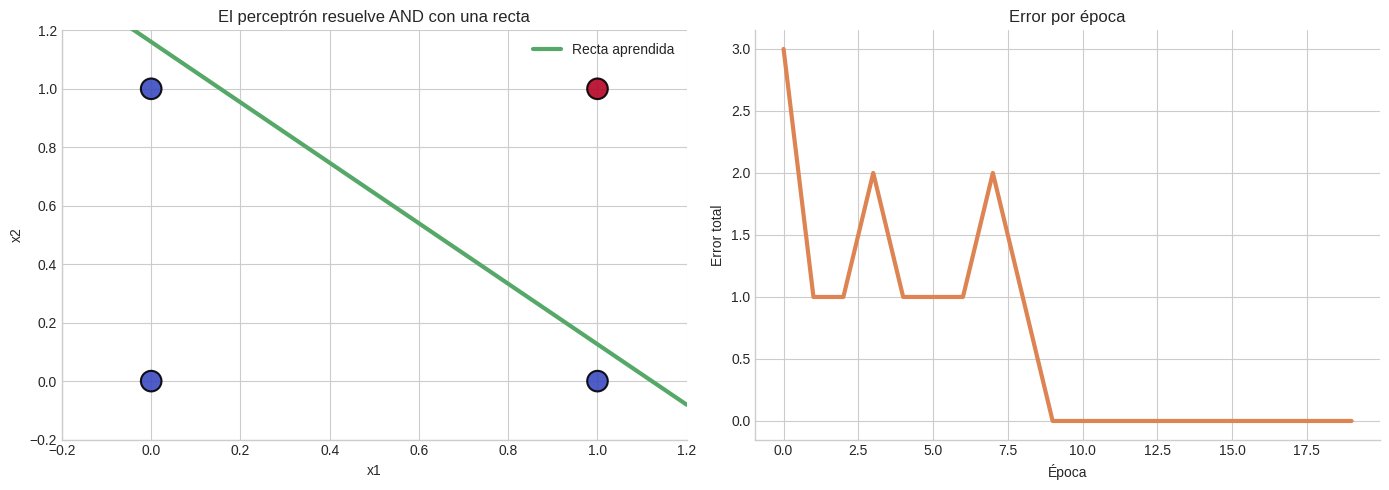

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    X_and[:, 0].numpy(),
    X_and[:, 1].numpy(),
    c=y_and.squeeze().numpy(),
    cmap="coolwarm",
    s=220,
    edgecolors="black",
    linewidth=1.5,
    alpha=0.9,
 )

x_line = np.linspace(-0.2, 1.2, 200)
w1, w2 = perceptron_and.weights.numpy()
b = perceptron_and.bias.item()
if abs(w2) > 1e-6:
    y_line = -(w1 * x_line + b) / w2
    axes[0].plot(x_line, y_line, color=COLORS["green"], linewidth=3, label="Recta aprendida")

axes[0].set_title("El perceptrón resuelve AND con una recta")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_xlim(-0.2, 1.2)
axes[0].set_ylim(-0.2, 1.2)
axes[0].legend()

axes[1].plot(and_errors, color=COLORS["orange"], linewidth=3)
axes[1].set_title("Error por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Error total")

plt.tight_layout()
plt.show()

### ¿Por qué AND sí funciona?

En la puerta AND, los puntos de la clase 1 quedan “arrinconados” en una esquina del plano. Eso permite que una sola recta los separe del resto.

Este es un buen primer éxito: muestra que el perceptrón **no está roto**. Simplemente tiene una capacidad geométrica limitada.

La siguiente pregunta natural es más interesante: **¿qué ocurre cuando la geometría del problema exige más que una sola recta?**

### El límite del perceptrón: el problema XOR

El XOR es el contraejemplo clásico que cambió la historia de las redes neuronales.

Los puntos positivos están en esquinas opuestas y los negativos ocupan las otras dos esquinas. Esa disposición “cruzada” impide que una sola recta separe correctamente ambas clases.

Dicho de otro modo: si el perceptrón solo puede dibujar un hiperplano, entonces en 2D solo dispone de una línea recta. Y una línea recta nunca puede dejar juntos los dos puntos de la clase 1 sin también arrastrar uno de los negativos.

Por eso, cuando el perceptrón falla en XOR, no falla por falta de épocas ni por una mala semilla aleatoria: falla porque el problema **no es linealmente separable**.

Época  1 | error total = 1
Época  2 | error total = 1
Época  3 | error total = 2
Época  5 | error total = 2
Época 10 | error total = 3
Época 20 | error total = 2
Época 40 | error total = 2
Época 60 | error total = 2

Predicciones finales del perceptrón sobre XOR:
x = [0. 0.] -> pred = 0 | real = 0
x = [0. 1.] -> pred = 0 | real = 1
x = [1. 0.] -> pred = 0 | real = 1
x = [1. 1.] -> pred = 0 | real = 0


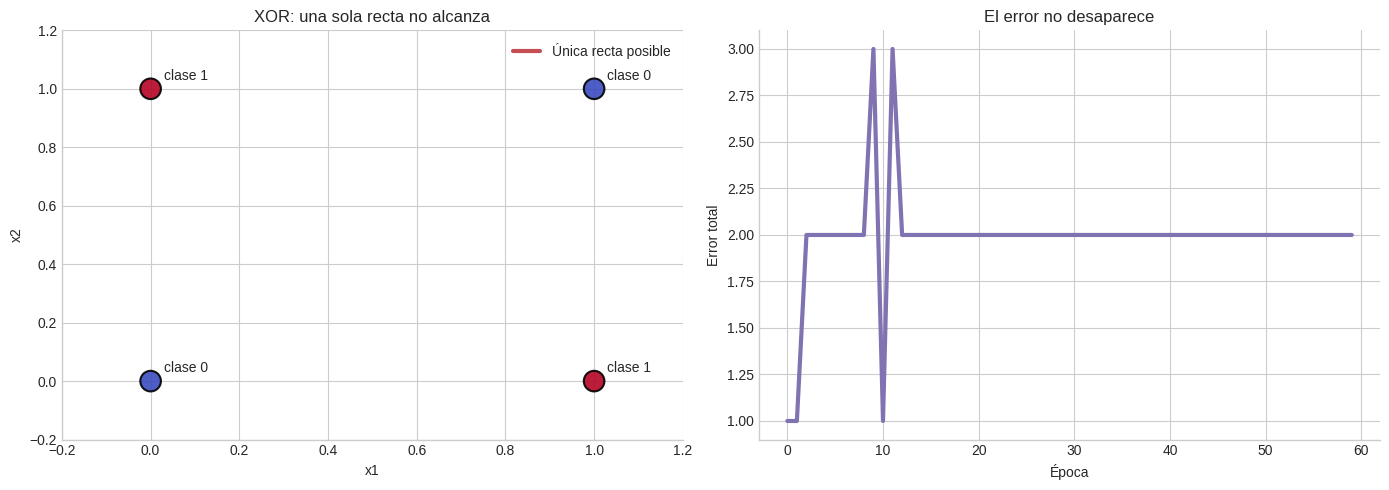

In [4]:
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

perceptron_xor = Perceptron(input_size=2, learning_rate=0.1)
xor_errors = []

for epoch in range(60):
    error = perceptron_xor.train_step(X_xor, y_xor)
    xor_errors.append(error)
    if epoch in {0, 1, 2, 4, 9, 19, 39, 59}:
        print(f"Época {epoch + 1:>2} | error total = {error:.0f}")

print("\nPredicciones finales del perceptrón sobre XOR:")
for inputs, target in zip(X_xor, y_xor):
    prediction = perceptron_xor.forward(inputs).item()
    print(f"x = {inputs.numpy()} -> pred = {prediction:.0f} | real = {target.item():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    X_xor[:, 0].numpy(),
    X_xor[:, 1].numpy(),
    c=y_xor.squeeze().numpy(),
    cmap="coolwarm",
    s=220,
    edgecolors="black",
    linewidth=1.5,
    alpha=0.9,
 )

x_line = np.linspace(-0.2, 1.2, 200)
w1, w2 = perceptron_xor.weights.numpy()
b = perceptron_xor.bias.item()
if abs(w2) > 1e-6:
    y_line = -(w1 * x_line + b) / w2
    axes[0].plot(x_line, y_line, color=COLORS["red"], linewidth=3, label="Única recta posible")

for point, label in zip(X_xor, y_xor.squeeze()):
    axes[0].annotate(f"clase {int(label.item())}", (point[0].item() + 0.03, point[1].item() + 0.03))

axes[0].set_title("XOR: una sola recta no alcanza")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_xlim(-0.2, 1.2)
axes[0].set_ylim(-0.2, 1.2)
axes[0].legend()

axes[1].plot(xor_errors, color=COLORS["purple"], linewidth=3)
axes[1].set_title("El error no desaparece")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Error total")

plt.tight_layout()
plt.show()

## 2. Funciones de Activación

Si apiláramos capas lineales sin activación, toda la red seguiría siendo equivalente a una sola transformación lineal.

Las funciones de activación rompen esa rigidez. Intuitivamente, permiten **doblar, estirar y deformar el espacio de características**. Lo que antes estaba “cruzado” o mezclado puede reorganizarse en una representación interna donde una separación lineal sí sea posible.

Esa es la intuición profunda detrás de un MLP:
- la primera capa transforma el espacio,
- la activación introduce no linealidad,
- la salida final separa en ese nuevo espacio.

En dimensiones superiores no lo vemos directamente, pero podemos pensarlo así: la red aprende una nueva geometría donde problemas como XOR dejan de ser imposibles.

**Ancla práctica:** en muchos problemas de clasificación binaria, `sigmoid` aparece en la **capa de salida** porque produce probabilidades entre 0 y 1. En cambio, `ReLU` suele usarse en las **capas ocultas** porque entrena mejor y permite construir fronteras más flexibles.

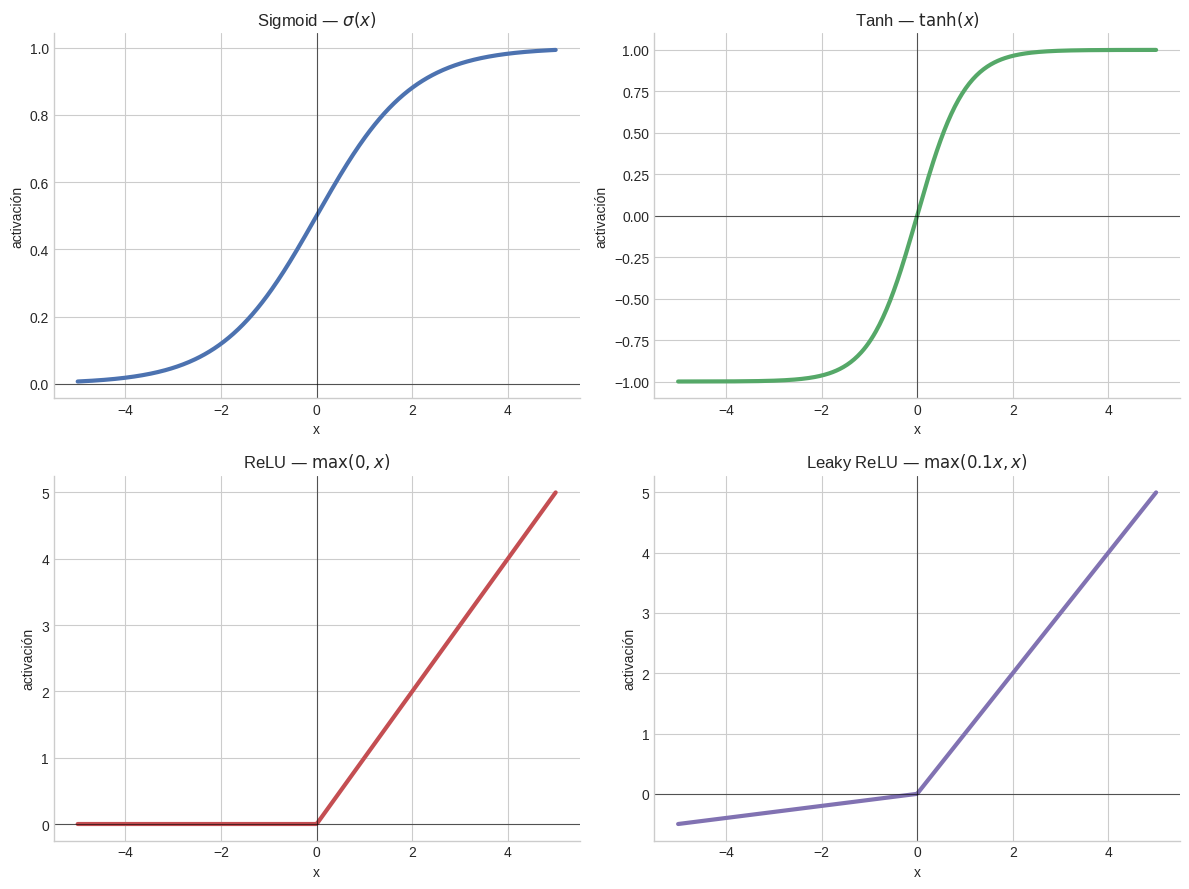

Idea intuitiva:
- Sigmoid y tanh comprimen valores en rangos acotados.
- ReLU deja pasar valores positivos y recorta los negativos.
- Leaky ReLU evita que la pendiente sea exactamente cero del lado negativo.
- En práctica: sigmoid suele verse en la salida binaria y ReLU en capas ocultas.
- Todas introducen no linealidad, que es lo que permite deformar el espacio de representación.


In [5]:
x_values = torch.linspace(-5, 5, 400)
activation_curves = {
    "Sigmoid": (torch.sigmoid(x_values), COLORS["blue"], r"$\sigma(x)$"),
    "Tanh": (torch.tanh(x_values), COLORS["green"], r"$\tanh(x)$"),
    "ReLU": (F.relu(x_values), COLORS["red"], r"$\max(0, x)$"),
    "Leaky ReLU": (F.leaky_relu(x_values, negative_slope=0.1), COLORS["purple"], r"$\max(0.1x, x)$"),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (name, (values, color, formula)) in zip(axes, activation_curves.items()):
    ax.plot(x_values.numpy(), values.numpy(), color=color, linewidth=3)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_title(f"{name} — {formula}")
    ax.set_xlabel("x")
    ax.set_ylabel("activación")

plt.tight_layout()
plt.show()

print("Idea intuitiva:")
print("- Sigmoid y tanh comprimen valores en rangos acotados.")
print("- ReLU deja pasar valores positivos y recorta los negativos.")
print("- Leaky ReLU evita que la pendiente sea exactamente cero del lado negativo.")
print("- En práctica: sigmoid suele verse en la salida binaria y ReLU en capas ocultas.")
print("- Todas introducen no linealidad, que es lo que permite deformar el espacio de representación.")

## 3. Red Neuronal Multicapa (MLP)

El siguiente salto conceptual es agregar una capa oculta.

Eso cambia todo: ahora la red ya no intenta separar los datos directamente en el espacio original, sino que primero construye una representación intermedia y luego clasifica en ese nuevo espacio.

Esta es la motivación exacta para pasar del perceptrón al MLP:
- el perceptrón solo traza una frontera lineal en el espacio original,
- el MLP aprende una transformación no lineal,
- después de esa transformación, una separación simple puede volverse suficiente.

En otras palabras: el MLP no “rompe” XOR a fuerza bruta; lo resuelve porque aprende una representación mejor.

### Implementación en PyTorch

Vamos a usar una arquitectura mínima pero suficiente para XOR:
- entrada de 2 variables,
- una capa oculta pequeña,
- una salida sigmoidea que representa la probabilidad de pertenecer a la clase 1.

In [6]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size=2, hidden_size=4, output_size=1):
        super().__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.tanh(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

model_xor = SimpleMLP(input_size=2, hidden_size=4, output_size=1)
print(model_xor)
print(f"\nNúmero total de parámetros: {sum(parameter.numel() for parameter in model_xor.parameters())}")

SimpleMLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
)

Número total de parámetros: 17


### Entrenamiento del MLP para XOR

Ahora sí tenemos capacidad para aprender una frontera no lineal. Observá dos señales:
- la pérdida debería bajar de manera sostenida,
- las predicciones finales deberían acercarse mucho a 0 o 1 según corresponda.

Época    1 | pérdida = 0.6947
Época    2 | pérdida = 0.6926
Época    3 | pérdida = 0.6883
Época   10 | pérdida = 0.6330
Época  100 | pérdida = 0.0035
Época  500 | pérdida = 0.0004
Época 1000 | pérdida = 0.0002
Época 2000 | pérdida = 0.0000
Época 4000 | pérdida = 0.0000

Predicciones finales del MLP sobre XOR:
x = [0. 0.] -> prob = 0.0000 | pred = 0 | real = 0
x = [0. 1.] -> prob = 1.0000 | pred = 1 | real = 1
x = [1. 0.] -> prob = 1.0000 | pred = 1 | real = 1
x = [1. 1.] -> prob = 0.0000 | pred = 0 | real = 0


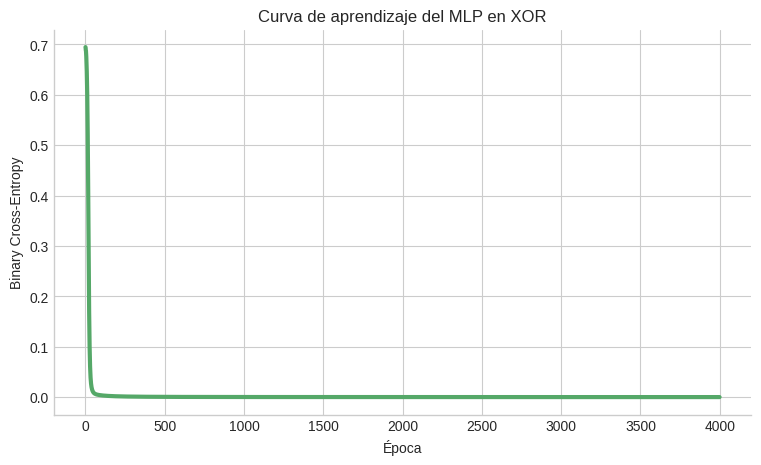

In [7]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model_xor.parameters(), lr=0.1)
xor_losses = []

for epoch in range(4000):
    predictions = model_xor(X_xor)
    loss = criterion(predictions, y_xor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    xor_losses.append(loss.item())

    if epoch in {0, 1, 2, 9, 99, 499, 999, 1999, 3999}:
        print(f"Época {epoch + 1:>4} | pérdida = {loss.item():.4f}")

with torch.no_grad():
    final_predictions = model_xor(X_xor)

print("\nPredicciones finales del MLP sobre XOR:")
for inputs, target, prediction in zip(X_xor, y_xor, final_predictions):
    print(
        f"x = {inputs.numpy()} -> prob = {prediction.item():.4f} | "
        f"pred = {(prediction.item() >= 0.5):.0f} | real = {target.item():.0f}"
    )

plt.figure(figsize=(9, 5))
plt.plot(xor_losses, color=COLORS["green"], linewidth=3)
plt.title("Curva de aprendizaje del MLP en XOR")
plt.xlabel("Época")
plt.ylabel("Binary Cross-Entropy")
plt.show()

### Visualización de la frontera de decisión

Lo más interesante no es solo que el MLP acierte, sino **cómo** lo logra.

La frontera de decisión ya no tiene por qué ser una recta. Gracias a la activación no lineal, la red puede combinar varias regiones lineales locales y construir una separación curva que se adapte al patrón XOR.

Primero observemos la frontera en el espacio original. Después veremos una pista de la representación interna que la red aprendió.

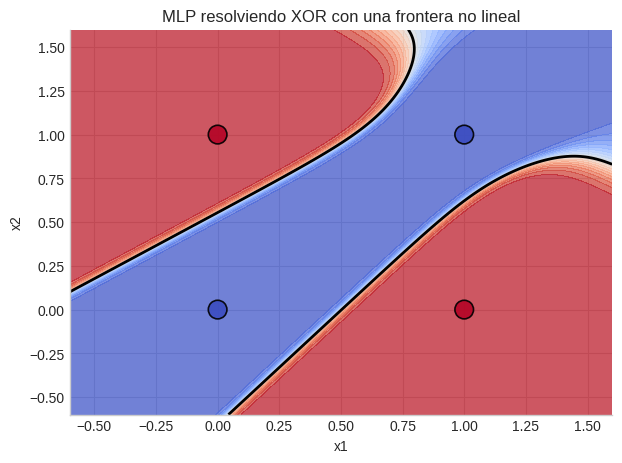

In [8]:
def plot_decision_boundary(model, X, y, scaler=None, title="", ax=None, levels=25):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)

    if isinstance(y, torch.Tensor):
        y_np = y.detach().cpu().numpy().reshape(-1)
    else:
        y_np = np.asarray(y).reshape(-1)

    x_min, x_max = X_np[:, 0].min() - 0.6, X_np[:, 0].max() + 0.6
    y_min, y_max = X_np[:, 1].min() - 0.6, X_np[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if scaler is not None:
        grid_for_model = scaler.transform(grid)
    else:
        grid_for_model = grid

    grid_tensor = torch.tensor(grid_for_model, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        probabilities = model(grid_tensor).cpu().numpy().reshape(xx.shape)

    contour = ax.contourf(xx, yy, probabilities, levels=levels, cmap="coolwarm", alpha=0.75)
    ax.contour(xx, yy, probabilities, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(
        X_np[:, 0],
        X_np[:, 1],
        c=y_np,
        cmap="coolwarm",
        s=180 if len(X_np) <= 10 else 35,
        edgecolors="black",
        linewidth=1.2,
        alpha=0.9,
    )
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    return contour

fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(
    model_xor,
    X_xor,
    y_xor,
    title="MLP resolviendo XOR con una frontera no lineal",
    ax=ax,
    levels=20,
 )
plt.show()

### Una mirada al espacio oculto $\mathcal{H}$

El punto central no es que el MLP “dibuje magia”, sino que aprende una **representación interna** donde el problema se vuelve mucho más fácil de separar.

En la capa oculta, la red construye nuevas coordenadas a partir de la entrada:

$$\mathbf{h} = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b})$$

Esa transformación combina dos ingredientes:

1. un paso afín que rota, escala y traslada el espacio,
2. un paso no lineal que deforma la geometría.

En este notebook vamos a mirar esa representación de una manera **aproximada pero útil**:

- primero extraemos las activaciones ocultas reales,
- luego las proyectamos a 2D con **PCA** para poder verlas,
- y finalmente ajustamos una recta separadora **solo en esa proyección 2D**.

Importante: esa recta es una **herramienta visual auxiliar**. Sirve para mostrar que la representación aprendida **sugiere separabilidad lineal**, pero **no** es el hiperplano exacto del MLP ni una proyección exacta de $w_{out}$.

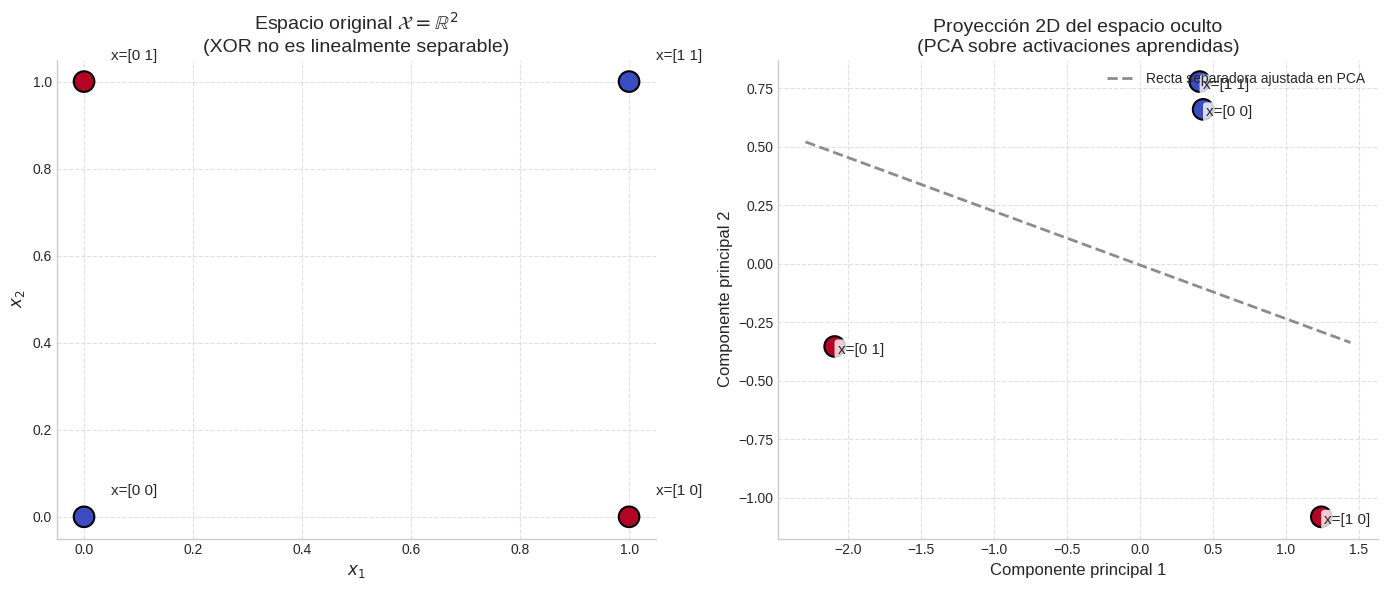

In [9]:
# 1. Extraemos las activaciones ocultas reales en R^4
with torch.no_grad():
    h_4d = torch.tanh(model_xor.hidden(X_xor)).numpy()

y_colors = y_xor.squeeze().numpy()

# 2. Las proyectamos a 2D con PCA para poder visualizarlas
pca = PCA(n_components=2)
h_2d = pca.fit_transform(h_4d)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Espacio original ---
ax1.scatter(
    X_xor[:, 0],
    X_xor[:, 1],
    c=y_colors,
    cmap="coolwarm",
    s=220,
    edgecolors="black",
    linewidth=1.5,
    zorder=3,
 )
ax1.set_title("Espacio original $\\mathcal{X} = \\mathbb{R}^2$\n(XOR no es linealmente separable)", fontsize=14)
ax1.set_xlabel("$x_1$", fontsize=12)
ax1.set_ylabel("$x_2$", fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.6, zorder=0)

for point in X_xor.numpy():
    ax1.annotate(f"x={point.astype(int)}", (point[0] + 0.05, point[1] + 0.05), fontsize=11)

# --- Subplot 2: Proyección PCA del espacio oculto ---
ax2.scatter(
    h_2d[:, 0],
    h_2d[:, 1],
    c=y_colors,
    cmap="coolwarm",
    s=220,
    edgecolors="black",
    linewidth=1.5,
    zorder=3,
 )
ax2.set_title("Proyección 2D del espacio oculto\n(PCA sobre activaciones aprendidas)", fontsize=14)
ax2.set_xlabel("Componente principal 1", fontsize=12)
ax2.set_ylabel("Componente principal 2", fontsize=12)
ax2.grid(True, linestyle="--", alpha=0.6, zorder=0)

for i, point in enumerate(h_2d):
    ax2.annotate(
        f"x={X_xor[i].numpy().astype(int)}",
        (point[0] + 0.02, point[1] - 0.03),
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"),
    )

# 3. Ajustamos un separador lineal auxiliar en la proyección PCA
clf = LogisticRegression(C=1e5, random_state=42).fit(h_2d, y_colors)
w1, w2 = clf.coef_[0]
b = clf.intercept_[0]

x_vals = np.array([h_2d[:, 0].min() - 0.2, h_2d[:, 0].max() + 0.2])
y_vals = -(w1 * x_vals + b) / w2

ax2.plot(
    x_vals,
    y_vals,
    color=COLORS["gray"],
    linestyle="--",
    linewidth=2,
    label="Recta separadora ajustada en PCA",
 )
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Redes Profundas

Si una capa oculta ya puede resolver XOR, ¿para qué queremos más profundidad?

Porque en problemas más complejos necesitamos construir representaciones cada vez más ricas. Cada capa puede combinar y refinar lo aprendido por la anterior.

En esta sección vamos a comparar arquitecturas en datasets sintéticos donde la geometría de la frontera es más interesante.

### Generación de datasets

Vamos a usar tres problemas con dificultad creciente:
- uno linealmente separable,
- uno con forma de lunas,
- uno con círculos concéntricos.

La comparación ayuda a ver cuándo una frontera lineal basta y cuándo necesitamos más capacidad expresiva.

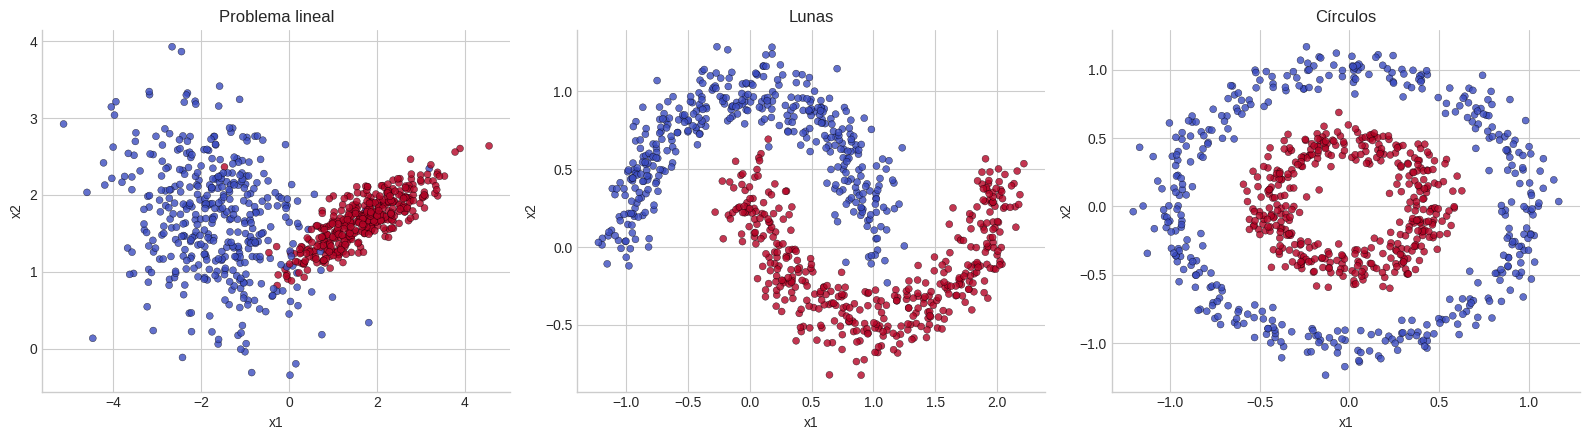

In [10]:
n_samples = 800

X_circles, y_circles = make_circles(
    n_samples=n_samples, noise=0.08, factor=0.45, random_state=42
 )
X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.12, random_state=42)
X_linear, y_linear = make_classification(
    n_samples=n_samples,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.7,
    random_state=42,
 )

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
datasets_to_plot = [
    (X_linear, y_linear, "Problema lineal"),
    (X_moons, y_moons, "Lunas"),
    (X_circles, y_circles, "Círculos"),
]

for ax, (X_data, y_data, title) in zip(axes, datasets_to_plot):
    ax.scatter(
        X_data[:, 0],
        X_data[:, 1],
        c=y_data,
        cmap="coolwarm",
        s=25,
        edgecolors="black",
        linewidth=0.3,
        alpha=0.8,
    )
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

### Arquitecturas profundas

Vamos a construir una clase flexible para probar distintas profundidades.

La hipótesis a observar es esta: a medida que aumenta la capacidad del modelo, puede representar fronteras más complejas. Pero esa misma capacidad también puede volverse peligrosa si no la regularizamos.

In [11]:
class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size=1, activation="relu"):
        super().__init__()
        layers = []
        previous_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_size, hidden_size))
            previous_size = hidden_size

        self.hidden_layers = nn.ModuleList(layers)
        self.output_layer = nn.Linear(previous_size, output_size)
        self.activation = activation

    def _activate(self, x):
        if self.activation == "relu":
            return F.relu(x)
        if self.activation == "tanh":
            return torch.tanh(x)
        if self.activation == "sigmoid":
            return torch.sigmoid(x)
        raise ValueError(f"Activación no soportada: {self.activation}")

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self._activate(layer(x))
        return torch.sigmoid(self.output_layer(x))

architectures = {
    "Superficial": [8],
    "Media": [16, 8],
    "Profunda": [32, 16, 8],
}

for name, hidden_sizes in architectures.items():
    model = DeepNN(input_size=2, hidden_sizes=hidden_sizes, output_size=1, activation="relu")
    n_params = sum(parameter.numel() for parameter in model.parameters())
    print(f"{name:>11} | capas ocultas = {hidden_sizes} | parámetros = {n_params}")

Superficial | capas ocultas = [8] | parámetros = 33
      Media | capas ocultas = [16, 8] | parámetros = 193
   Profunda | capas ocultas = [32, 16, 8] | parámetros = 769


### Funciones auxiliares de entrenamiento

A partir de acá vamos a reutilizar las mismas herramientas varias veces:
- preparar datos,
- entrenar un modelo,
- evaluar precisión,
- graficar curvas de pérdida.

Esto nos permite concentrarnos en la pregunta conceptual de cada experimento.

> **Nota didáctica:** estos datasets son pequeños. Por eso, en este notebook entrenamos con **full-batch** (todo el tensor de una vez) en lugar de usar `Dataset` y `DataLoader`. Es una simplificación deliberada: acá queremos poner el foco en la geometría, las fronteras de decisión y la comparación entre modelos.

In [12]:
def prepare_binary_classification_data(
    X,
    y,
    test_size=0.2,
    val_size=0.25,
    random_state=42,
    scale=True,
 ):
    """
    Hace un split en dos etapas.

    1. `test_size` define qué fracción total se separa primero como holdout.
    2. `val_size` define qué fracción de ese holdout termina siendo test.
       El resto del holdout se usa como validación.

    Ejemplo:
    - `test_size=0.3` crea un holdout total del 30%.
    - `val_size=0.5` divide ese holdout en mitades: 15% validación y 15% test.
    """
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=val_size,
        stratify=y_temp,
        random_state=random_state,
    )

    scaler = StandardScaler() if scale else None
    if scaler is not None:
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

    to_tensor = lambda array: torch.tensor(array, dtype=torch.float32)
    return {
        "X_train": to_tensor(X_train),
        "y_train": to_tensor(y_train).reshape(-1, 1),
        "X_val": to_tensor(X_val),
        "y_val": to_tensor(y_val).reshape(-1, 1),
        "X_test": to_tensor(X_test),
        "y_test": to_tensor(y_test).reshape(-1, 1),
        "scaler": scaler,
    }

def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=400,
    lr=0.01,
    weight_decay=0.0,
    verbose=False,
    track_best=True,
 ):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "val_loss": [],
        "best_epoch": None,
        "best_val_loss": None,
        "best_state_dict": None,
    }

    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        train_predictions = model(X_train)
        train_loss = criterion(train_predictions, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(X_val)
            val_loss = criterion(val_predictions, y_val)

        train_loss_value = train_loss.item()
        val_loss_value = val_loss.item()
        history["train_loss"].append(train_loss_value)
        history["val_loss"].append(val_loss_value)

        if track_best and val_loss_value < best_val_loss:
            best_val_loss = val_loss_value
            history["best_val_loss"] = val_loss_value
            history["best_epoch"] = epoch + 1
            history["best_state_dict"] = copy.deepcopy(model.state_dict())

        if verbose and epoch in {0, 1, 2, 9, 49, 99, epochs - 1}:
            print(
                f"Época {epoch + 1:>3} | train = {train_loss_value:.4f} | "
                f"val = {val_loss_value:.4f}"
            )

    if not track_best:
        history["best_epoch"] = int(np.argmin(history["val_loss"])) + 1
        history["best_val_loss"] = min(history["val_loss"])

    return history

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        probabilities = model(X)
        predictions = (probabilities >= 0.5).float()
        accuracy = (predictions == y).float().mean().item()
    return accuracy

def build_best_checkpoint_model(model, history):
    best_model = copy.deepcopy(model)
    if history.get("best_state_dict") is not None:
        best_model.load_state_dict(history["best_state_dict"])
    return best_model

def plot_loss_curves(history, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["train_loss"], label="Train", linewidth=3, color=COLORS["blue"])
    ax.plot(history["val_loss"], label="Validation", linewidth=3, color=COLORS["orange"])
    ax.set_title(title)
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend()
    return ax

### Entrenamiento en el dataset de círculos

Los círculos concentran una idea importante: en el espacio original no hay una recta simple que resuelva el problema, pero una red suficientemente expresiva puede construir una frontera cerrada.

Vamos a mirar simultáneamente la curva de pérdida y la frontera aprendida.

Época   1 | train = 0.7153 | val = 0.7061
Época   2 | train = 0.7056 | val = 0.6994
Época   3 | train = 0.6999 | val = 0.6947
Época  10 | train = 0.6568 | val = 0.6486
Época  50 | train = 0.2931 | val = 0.2916
Época 100 | train = 0.1974 | val = 0.1973
Época 500 | train = 0.0319 | val = 0.0328

Accuracy train: 1.000
Accuracy test:  1.000


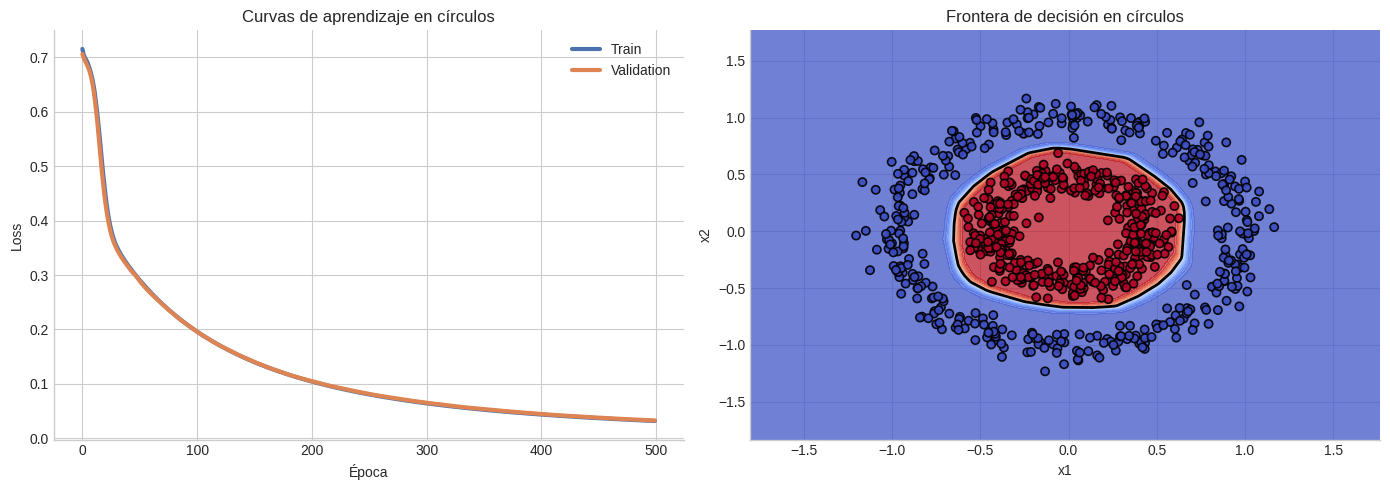

In [13]:
circles_data = prepare_binary_classification_data(X_circles, y_circles, test_size=0.3, val_size=0.5)

model_circles = DeepNN(input_size=2, hidden_sizes=[32, 16, 8], output_size=1, activation="relu")
circles_history = train_model(
    model_circles,
    circles_data["X_train"],
    circles_data["y_train"],
    circles_data["X_val"],
    circles_data["y_val"],
    epochs=500,
    lr=0.01,
    verbose=True,
 )

circles_train_acc = evaluate_model(model_circles, circles_data["X_train"], circles_data["y_train"])
circles_test_acc = evaluate_model(model_circles, circles_data["X_test"], circles_data["y_test"])

print(f"\nAccuracy train: {circles_train_acc:.3f}")
print(f"Accuracy test:  {circles_test_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_loss_curves(circles_history, "Curvas de aprendizaje en círculos", ax=axes[0])
plot_decision_boundary(
    model_circles,
    X_circles,
    y_circles,
    scaler=circles_data["scaler"],
    title="Frontera de decisión en círculos",
    ax=axes[1],
 )
plt.tight_layout()
plt.show()

### Comparación de arquitecturas

Ahora mantenemos fijo el problema y variamos la profundidad.

La idea no es decidir que “más profundo siempre es mejor”, sino observar que la arquitectura modifica la forma de la frontera y la capacidad del modelo.

 Superficial | acc test = 0.992 | parámetros = 33
       Media | acc test = 1.000 | parámetros = 193
    Profunda | acc test = 1.000 | parámetros = 769
Muy profunda | acc test = 1.000 | parámetros = 2945


arquitectura,hidden_sizes,parámetros,test_accuracy
Media,"[16, 8]",193,1.000
Profunda,"[32, 16, 8]",769,1.000
Muy profunda,"[64, 32, 16, 8]",2945,1.000
Superficial,[8],33,0.992


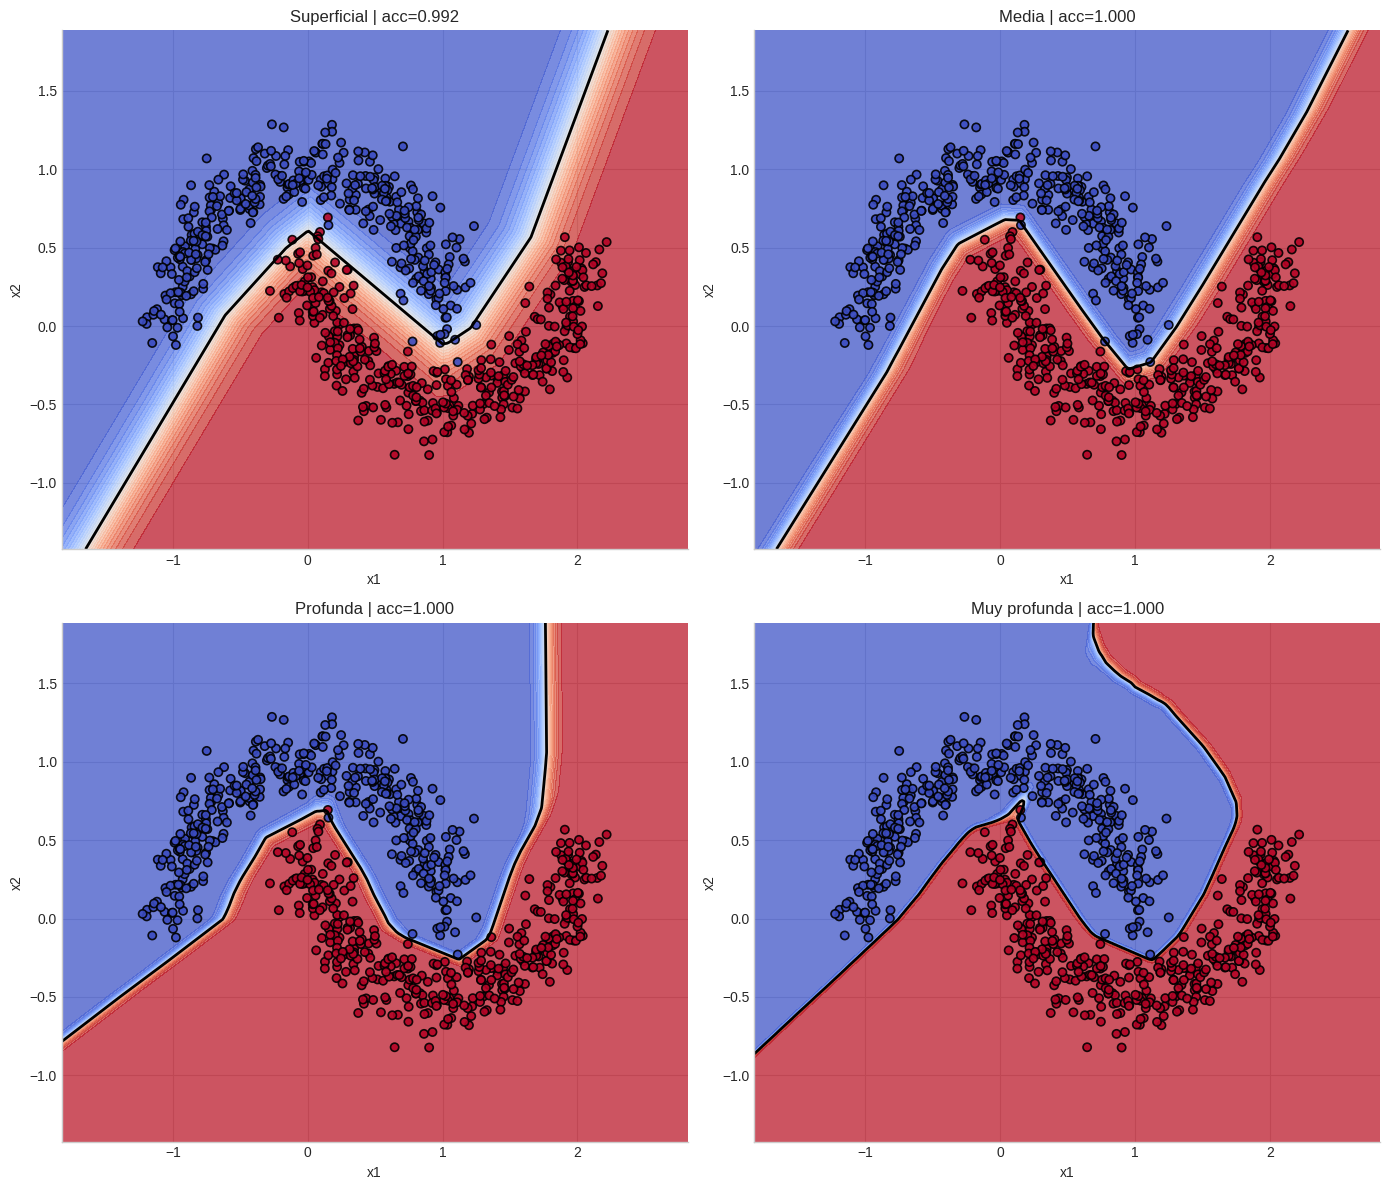

In [14]:
moons_data = prepare_binary_classification_data(X_moons, y_moons, test_size=0.3, val_size=0.5)

architecture_grid = {
    "Superficial": [8],
    "Media": [16, 8],
    "Profunda": [32, 16, 8],
    "Muy profunda": [64, 32, 16, 8],
}

comparison_results = {}
comparison_rows = []

for name, hidden_sizes in architecture_grid.items():
    model = DeepNN(input_size=2, hidden_sizes=hidden_sizes, output_size=1, activation="relu")
    history = train_model(
        model,
        moons_data["X_train"],
        moons_data["y_train"],
        moons_data["X_val"],
        moons_data["y_val"],
        epochs=350,
        lr=0.01,
        verbose=False,
    )
    test_accuracy = evaluate_model(model, moons_data["X_test"], moons_data["y_test"])
    n_params = sum(parameter.numel() for parameter in model.parameters())
    comparison_results[name] = {
        "model": model,
        "test_accuracy": test_accuracy,
        "params": n_params,
        "history": history,
        "hidden_sizes": hidden_sizes,
    }
    comparison_rows.append(
        {
            "arquitectura": name,
            "hidden_sizes": str(hidden_sizes),
            "parámetros": n_params,
            "test_accuracy": test_accuracy,
        }
    )
    print(f"{name:>12} | acc test = {test_accuracy:.3f} | parámetros = {n_params}")

comparison_df = pd.DataFrame(comparison_rows).sort_values("test_accuracy", ascending=False)
display(comparison_df.style.format({"test_accuracy": "{:.3f}"}).hide(axis="index"))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, (name, result) in zip(axes, comparison_results.items()):
    plot_decision_boundary(
        result["model"],
        X_moons,
        y_moons,
        scaler=moons_data["scaler"],
        title=f"{name} | acc={result['test_accuracy']:.3f}",
        ax=ax,
    )

plt.tight_layout()
plt.show()

## 5. Técnicas de Regularización

Hasta ahora vimos cómo aumentar capacidad. Ahora toca la pregunta complementaria: **¿cómo evitamos que esa capacidad se transforme en sobreajuste?**

Para que el efecto sea visible, vamos a construir un experimento deliberadamente incómodo:
- dataset `make_moons`,
- ruido alto (`noise=0.3`),
- pocos datos de entrenamiento,
- una red grande con muchísima flexibilidad.

La idea es provocar una situación donde el modelo sin regularizar pueda empezar a memorizar el ruido. Después compararemos esa conducta con una red similar, pero con `Dropout`.

En esta versión del notebook vamos a distinguir explícitamente entre dos cosas:

- el **modelo final** después de todas las épocas,
- el **mejor checkpoint de validación**, es decir, el estado que logró la menor pérdida de validación durante el entrenamiento.

Eso evita una confusión común en clase: el mejor punto de validación no siempre coincide con el estado final, especialmente cuando aparece sobreajuste.

Antes de ejecutar, hacé esta predicción:
1. ¿Cuál de los dos modelos va a bajar más rápido la pérdida de entrenamiento?
2. ¿Cuál esperás que conserve mejor la pérdida de validación?
3. ¿Qué frontera de decisión imaginás más suave?

Sin regularización
- Estado final:
  train loss = 0.0000 | val loss = 6.6299
  acc train / val / test = 1.000 / 0.835 / 0.890
- Mejor checkpoint de validación:
  best val loss = 0.2464 (época 11)
  acc train / val / test = 0.897 / 0.923 / 0.791

Con Dropout
- Estado final:
  train loss = 0.1040 | val loss = 3.1196
  acc train / val / test = 0.974 / 0.901 / 0.868
- Mejor checkpoint de validación:
  best val loss = 0.2368 (época 22)
  acc train / val / test = 0.872 / 0.923 / 0.813



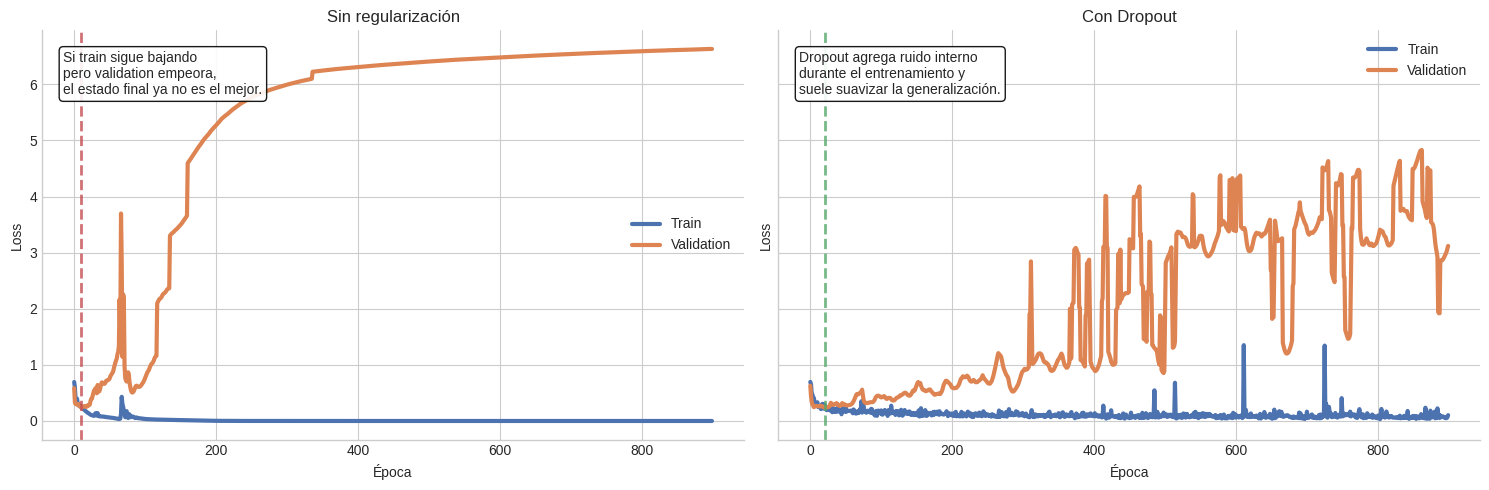

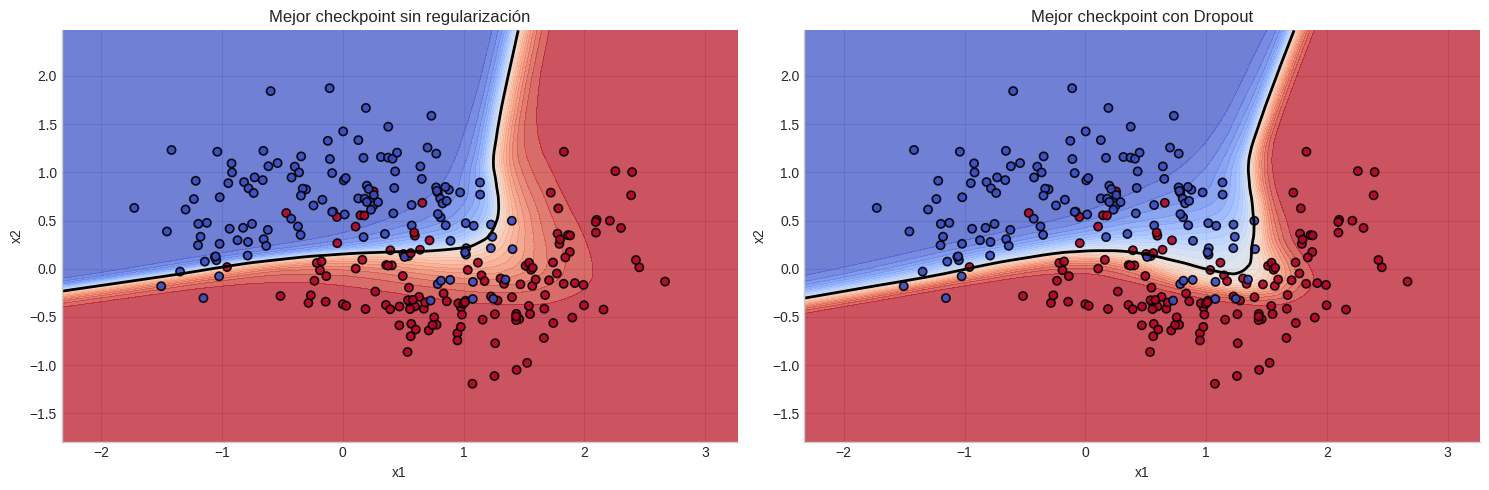

In [15]:
class RegularizedNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size=1, dropout_p=0.4):
        super().__init__()
        layers = []
        previous_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, output_size))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def collect_metrics(model, history, data):
    best_model = build_best_checkpoint_model(model, history)
    return {
        "final": {
            "train_acc": evaluate_model(model, data["X_train"], data["y_train"]),
            "val_acc": evaluate_model(model, data["X_val"], data["y_val"]),
            "test_acc": evaluate_model(model, data["X_test"], data["y_test"]),
            "train_loss": history["train_loss"][-1],
            "val_loss": history["val_loss"][-1],
        },
        "best": {
            "train_acc": evaluate_model(best_model, data["X_train"], data["y_train"]),
            "val_acc": evaluate_model(best_model, data["X_val"], data["y_val"]),
            "test_acc": evaluate_model(best_model, data["X_test"], data["y_test"]),
            "val_loss": history["best_val_loss"],
            "epoch": history["best_epoch"],
        },
        "best_model": best_model,
    }

# Forzamos artificialmente una situación propensa al sobreajuste:
# mucho ruido y pocos datos de entrenamiento.
X_noisy_moons, y_noisy_moons = make_moons(n_samples=260, noise=0.3, random_state=42)
noisy_moons_data = prepare_binary_classification_data(
    X_noisy_moons, y_noisy_moons, test_size=0.7, val_size=0.5, random_state=42
)

torch.manual_seed(42)
model_no_reg = DeepNN(
    input_size=2, hidden_sizes=[256, 256, 128, 64], output_size=1, activation="relu"
)

torch.manual_seed(42)
model_with_reg = RegularizedNN(
    input_size=2, hidden_sizes=[256, 256, 128, 64], output_size=1, dropout_p=0.4
)

history_no_reg = train_model(
    model_no_reg,
    noisy_moons_data["X_train"],
    noisy_moons_data["y_train"],
    noisy_moons_data["X_val"],
    noisy_moons_data["y_val"],
    epochs=900,
    lr=0.008,
    verbose=False,
)

history_with_reg = train_model(
    model_with_reg,
    noisy_moons_data["X_train"],
    noisy_moons_data["y_train"],
    noisy_moons_data["X_val"],
    noisy_moons_data["y_val"],
    epochs=900,
    lr=0.008,
    verbose=False,
)

metrics = {
    "Sin regularización": collect_metrics(model_no_reg, history_no_reg, noisy_moons_data),
    "Con Dropout": collect_metrics(model_with_reg, history_with_reg, noisy_moons_data),
}

for model_name, values in metrics.items():
    print(model_name)
    print("- Estado final:")
    print(f"  train loss = {values['final']['train_loss']:.4f} | val loss = {values['final']['val_loss']:.4f}")
    print(
        f"  acc train / val / test = {values['final']['train_acc']:.3f} / "
        f"{values['final']['val_acc']:.3f} / {values['final']['test_acc']:.3f}"
    )
    print("- Mejor checkpoint de validación:")
    print(f"  best val loss = {values['best']['val_loss']:.4f} (época {values['best']['epoch']})")
    print(
        f"  acc train / val / test = {values['best']['train_acc']:.3f} / "
        f"{values['best']['val_acc']:.3f} / {values['best']['test_acc']:.3f}"
    )
    print()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
plot_loss_curves(history_no_reg, "Sin regularización", ax=axes[0])
plot_loss_curves(history_with_reg, "Con Dropout", ax=axes[1])

axes[0].axvline(history_no_reg["best_epoch"] - 1, color=COLORS["red"], linestyle="--", linewidth=2, alpha=0.8)
axes[1].axvline(history_with_reg["best_epoch"] - 1, color=COLORS["green"], linestyle="--", linewidth=2, alpha=0.8)

axes[0].text(
    0.03,
    0.95,
    "Si train sigue bajando\npero validation empeora,\nel estado final ya no es el mejor.",
    transform=axes[0].transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
)
axes[1].text(
    0.03,
    0.95,
    "Dropout agrega ruido interno\ndurante el entrenamiento y\nsuele suavizar la generalización.",
    transform=axes[1].transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_decision_boundary(
    metrics["Sin regularización"]["best_model"],
    X_noisy_moons,
    y_noisy_moons,
    scaler=noisy_moons_data["scaler"],
    title="Mejor checkpoint sin regularización",
    ax=axes[0],
)
plot_decision_boundary(
    metrics["Con Dropout"]["best_model"],
    X_noisy_moons,
    y_noisy_moons,
    scaler=noisy_moons_data["scaler"],
    title="Mejor checkpoint con Dropout",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

## 6. Ejercicios interactivos (fill-in-the-blanks)

Ahora sí: en lugar de dejar consignas sueltas, quedan dos ejercicios listos para completar en clase.

La consigna es simple:
1. leer el esqueleto,
2. completar los espacios en blanco,
3. ejecutar,
4. comparar curvas y comportamiento del modelo.

Los dos focos son técnicas muy usadas en práctica: `weight decay` y `early stopping`.

In [16]:
# Ejercicio 1: completar L2 Regularization (Weight Decay)

def train_with_weight_decay(
    model,
    X_train, y_train, X_val, y_val,
    epochs=200,
    lr=0.01,
    weight_decay=None,  # Reemplazar None por un valor como 1e-3
):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=____,  # Completar con la variable correcta
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_predictions = model(X_train)
        train_loss = criterion(train_predictions, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(X_val)
            val_loss = criterion(val_predictions, y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

# Pista: el optimizador ya sabe aplicar regularización L2 si recibe el argumento correcto.
# Después de completar la función, compará estas curvas con las del modelo sin regularización.

In [17]:
# Ejercicio 2: completar Early Stopping

def train_with_early_stopping(
    model,
    X_train, y_train, X_val, y_val,
    epochs=400,
    lr=0.01,
    patience=None,  # Reemplazar None por un entero, por ejemplo 20
):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_predictions = model(X_train)
        train_loss = criterion(train_predictions, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(X_val)
            val_loss = criterion(val_predictions, y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= ____:  # Completar con la condición correcta
            print(f"Entrenamiento detenido en la época {epoch + 1}")
            break

    return train_losses, val_losses

# Pista: la idea es detener el entrenamiento cuando la validación lleva muchas épocas seguidas sin mejorar.
# Después de completarlo, compará cuántas épocas realmente necesitó el modelo.

### Pistas para los ejercicios

- En **L2 regularization**, el argumento correcto ya existe en `Adam`: solo hay que conectarlo bien con la variable `weight_decay`.
- En **Early Stopping**, la lógica central es contar cuántas épocas consecutivas no mejoran la pérdida de validación.
- Una vez completos, compará no solo la curva final sino también **cuándo** empieza a abrirse la brecha entre entrenamiento y validación.

## Resumen

En este notebook vimos una progresión conceptual muy importante:

### 1. Perceptrón
- Aprende una frontera lineal.
- En 2D, eso significa una sola recta.
- Por eso puede resolver AND, pero no XOR.

### 2. Activaciones y MLP
- Las activaciones introducen no linealidad.
- Esa no linealidad permite deformar el espacio.
- Un MLP con capa oculta puede construir fronteras curvas y resolver XOR.

### 3. Redes profundas
- Más capas permiten representar patrones más complejos.
- La arquitectura influye en la forma de la frontera y en la capacidad del modelo.

### 4. Regularización
- Un modelo muy flexible puede sobreajustar.
- `Dropout` ayuda a controlar ese sobreajuste.
- Las curvas de train/validation y las fronteras de decisión permiten verlo con claridad.

**Idea para llevarse:** en Deep Learning no solo importa si el modelo acierta, sino también qué geometría aprende y qué tan bien generaliza fuera de los datos de entrenamiento.